In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [4]:
from pathlib import Path
import pandas as pd

file_name = "train_digitRecog.csv"

# Search upward from current working directory and find the file by name
csv_path = None
for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    matches = list(root.rglob(file_name))
    if matches:
        csv_path = matches[0]
        break

if csv_path is None:
    raise FileNotFoundError(f"{file_name} not found in workspace search.")

df = pd.read_csv(csv_path)
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


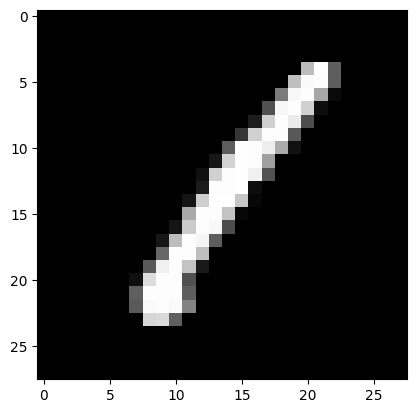

In [9]:
import matplotlib.pyplot as plt

plt.imshow(df.iloc[0, 1:].values.reshape(28, 28), cmap='gray')
plt.show()

In [10]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.shape, y_train.shape

((33600, 784), (33600,))

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.9648809523809524

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.decomposition import PCA
best_score = 0
best_n_components = 0
for i in range(1, 785):
    pca = PCA(n_components=i)  # Keep 95% of variance
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    X_train_pca.shape, X_test_pca.shape
    knn_pca = KNeighborsClassifier()
    knn_pca.fit(X_train_pca, y_train)
    score = knn_pca.score(X_test_pca, y_test)
    if score > best_score:
        best_score = score
        best_n_components = i

print(f"Best score: {best_score} with {best_n_components} components")

KeyboardInterrupt: 